# Closed-Loop Linear Model Predictive Control

This notebook demonstrates a closed-loop Model Predictive Control (MPC) simulation for a simple unstable linear 2D system using the `OCP` class.

In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

from model_predictive_control.ocp import OCP, linear_dynamics, quadratic_objective, terminal_quadratic_objective, state_bounds_constraints, control_bounds_constraints
from model_predictive_control.plots import plot_states, plot_controls, plot_mpc_trajectories

## 1. Linear System Dynamics

We define a generic unstable linear system $x_{k+1} = A x_k + B u_k$.

In [2]:
A = np.array([[1.0, 0.1], 
              [0.5, 1.0]]) 
B = np.array([[0.0], 
              [0.1]])

nx = A.shape[1]
nu = B.shape[1]

# Create discrete dynamics function
dynamics = linear_dynamics(A, B)

## 2. Objective Function and Constraints

We use a standard quadratic objective to penalize state deviations and control effort, and box constraints for safety.

In [3]:
# Objective matrices
Q = np.diag([100.0, 10.0])
R = np.array([[0.1]])

q_term = np.zeros(nx)
r_term = np.zeros(nu)
N_cross = np.zeros((nx, nu))

objective = quadratic_objective(Q, R, q_term, r_term, N_cross)

# Terminal objective
Qf = np.diag([1000.0, 100.0])
terminal_objective = terminal_quadratic_objective(Qf, q_term)

# Constraints
u_max_val = 50.0
u_min = np.array([-u_max_val])
u_max = np.array([u_max_val])

x_max_val = 2.0
x_min = np.array([-x_max_val, -x_max_val])
x_max = np.array([x_max_val, x_max_val])

state_bounds = state_bounds_constraints(x_min, x_max, nu)
control_bounds = control_bounds_constraints(u_min, u_max, nx)

x = ca.MX.sym('x', nx)
u = ca.MX.sym('u', nu)

in_eq_constraints = ca.Function('in_eq', [x, u], [ca.vertcat(state_bounds(x, u), control_bounds(x, u))])

## 3. OCP Setup and Closed-Loop Simulation

In [4]:
N_horizon = 20
N_sim = 40
dt = 0.1

ocp = OCP(
    N=N_horizon,
    dt=dt,
    objective=objective,
    dynamics=dynamics,
    terminal_objective=terminal_objective,
    in_eq_constraints=in_eq_constraints
)

# Setup using multiple shooting and ipopt
ocp.setup(
    method="multiple_shooting",
    dynamics_type="discrete",
    solver="ipopt",
    solver_opts={"print_level": 0}
)

# Simulation loop
x0_val = np.array([1.5, 0.0]) # Start near the bound
X_closed_loop = np.zeros((nx, N_sim + 1))
U_closed_loop = np.zeros((nu, N_sim))
X_open_loop = np.zeros((N_sim, nx, N_horizon + 1))

X_closed_loop[:, 0] = x0_val
current_x = x0_val

for k in range(N_sim):
    X_opt, U_opt, status = ocp.solve(current_x)
    
    # Extract first control action
    u_k = U_opt[:, 0]
    
    # Store predictions for plotting
    X_open_loop[k, :, :] = X_opt
    
    # Apply control to system
    x_next = A @ current_x + B @ u_k
    
    # Store results
    U_closed_loop[:, k] = u_k
    X_closed_loop[:, k+1] = x_next
    
    # Update current state
    current_x = x_next

print("Simulation finished.")


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 153.00us ( 12.75us)  37.48us (  3.12us)        12
       nlp_g  | 334.00us ( 27.83us)  72.25us (  6.02us)        12
  nlp_grad_f  | 196.00us ( 15.08us)  47.73us (  3.67us)        13
  nlp_hess_l  | 129.00us ( 11.73us)  32.09us (  2.92us)        11
   nlp_jac_g  | 224.00us ( 17.23us)  56.23us (  4.33us)        13
       total  |  88.43ms ( 88.43ms)  22.11ms ( 22.11ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  | 196.00us ( 13.07us)  49.16us (  3.28us)        15
       nlp_g  | 375

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  22.00us (  3.14us)  21.67us (  3.10us)         7
       nlp_g  |  52.00us (  7.43us)  41.63us (  5.95us)         7
  nlp_grad_f  |  29.00us (  3.62us)  27.72us (  3.47us)         8
  nlp_hess_l  |  19.00us (  3.17us)  17.07us (  2.85us)         6
   nlp_jac_g  |  34.00us (  4.25us)  33.64us (  4.21us)         8
       total  |  12.57ms ( 12.57ms)  11.89ms ( 11.89ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  28.00us (  4.67us)  18.38us (  3.06us)         6
       nlp_g  |  53.00us (  8.83us)  43.75us (  7.29us)         6
  nlp_grad_f  |  25.00us (  3.57us)  23.79us (  3.40us)         7
  nlp_hess_l  |  15.00us (  3.00us)  13.77us (  2.75us)         5
   nlp_jac_g  |  30.00us (  4.29us)  29.08us (  4.15us)         7
       total  |   9.57ms (  9.57ms)   9.53ms (  9.53ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  19.00us (  3.17us)  17.94us (  2.99us)         6
       nlp_g  |  42.00us (  7.00us)  34.90us (  5.82us)         6
  nlp_grad_f  |  25.00us (  3.57us)  25.12us (  3.59us)         7
  nlp_hess_l  |  15.00us (  3.00us)  14.25us (  2.85us)         5
   nlp_jac_g  |  32.00us (  4.57us)  30.10us (  4.30us)         7
       total  |  10.82ms ( 10.82ms)   9.99ms (  9.99ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |  19.00us (  3.17us)  17.66us (  2.94us)         6
       nlp_g  |  43.00us (  7.17us)  34.51us (  5.75us)         6
  nlp_grad_f  |  28.00us (  4.00us)  24.77us (  3.54us)         7
  nlp_hess_l  |  15.00us (  3.00us)  13.38us (  2.68us)         5
   nlp_jac_g  |  29.00us (  4.14us)  29.34us (  4.19us)         7
       total  |   9.52ms (  9.52ms)   9.52ms (  9.52ms)         1
      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp

## 4. Plot Results

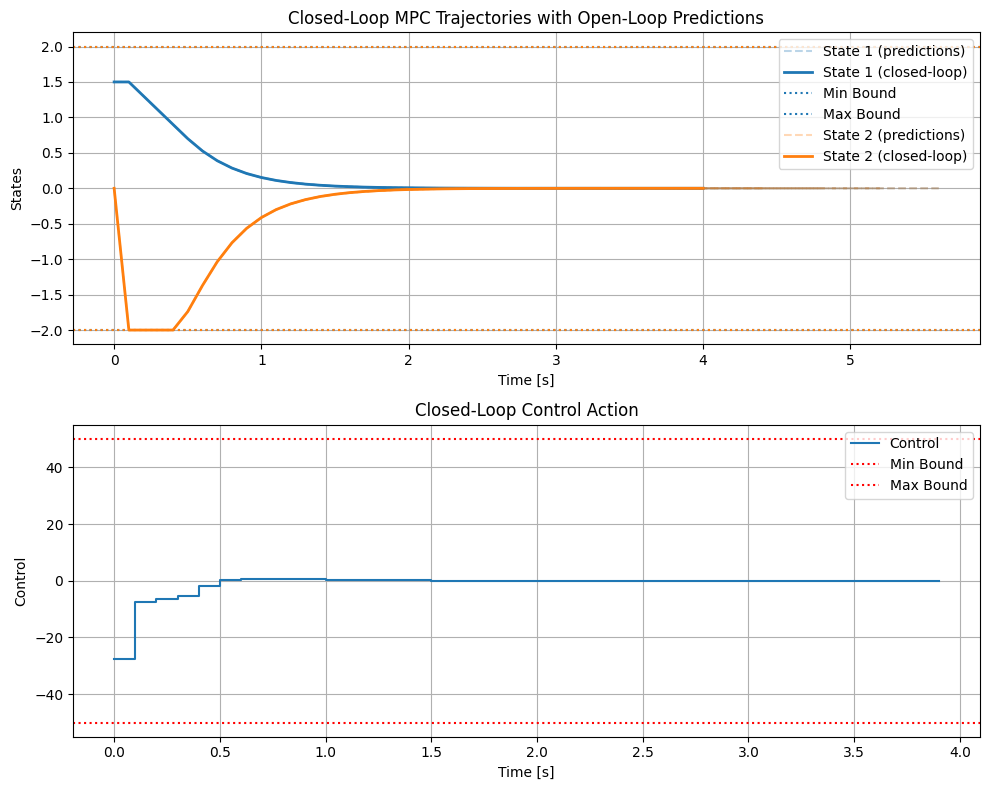

In [5]:
time = np.arange(N_sim + 1) * dt

fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Plot states with open loop predictions
plot_mpc_trajectories(
    time, 
    X_closed_loop, 
    X_open_loop, 
    labels=['State 1', 'State 2'], 
    fig=fig, 
    ax=axs[0], 
    title='Closed-Loop MPC Trajectories with Open-Loop Predictions',
    bounds=[(x_min[0], x_max[0]), (x_min[1], x_max[1])],
    step_interval=4
)

# Plot controls
plot_controls(
    time, 
    U_closed_loop, 
    labels=['Control'], 
    fig=fig, 
    ax=axs[1], 
    title='Closed-Loop Control Action',
    bounds=[(u_min[0], u_max[0])]
)

plt.tight_layout()
plt.show()